# 18. Reporte de titulaciones / educación

**Fuente:** `data/raw/ReporteTitulacionesEducacion.csv`  
**Salida:** `data/processed/reporte_titulaciones_educacion.csv`

Titulos academicos obtenidos por el personal (nivel, institucion, carrera, area de conocimiento, fecha de graduacion). Base de la formacion academica del perfil.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('ReporteTitulacionesEducacion.csv', low_memory=False)
df.head()

Leido ReporteTitulacionesEducacion.csv con encoding=utf-8-sig -> 74553 filas, 37 columnas


,IdPersona,NumeroIdentificacion,Apellidos,Nombres,IdTitulacion,Titulo,Estado,Nivel,Institucion,Pais,CodEstudiante,CodCarrera,CodCarrDivEspecializ,AreaCine,CampoCine,SubAreaCine,CampoSubCine,AreaFrascati,SubAreaFrascati,IdNomenclaturaTit,CodAreaFrascati,CodSubAreaFrascati,FechaGraduacion,RefArchivo,PromedioMateriasAprobadas,RefArchivoMateriasAprobadas,RankingGraduado,TotalGraduados,RefArchivoRankGraduado,RankingIes,RefArchivoRankIes,FechaSubidaArchivoTitulo,ValidadoThTitulo,ValidadoThMateriasAprobadas,ValidadoThRankGraduado,ValidadoThRankIes,IdPrograma
0,27668,0000000000011,OTERO ALVARADO,CARLOS GERARDO,0,ECONOMISTA CON MENCIÓN EN GESTIÓN EMPRESARIAL ...,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199409012.0,ECO,ECECOFI,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1999-01-14,"1,166886",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,10
1,25678,0000000006510,BORRERO SANABRIA,OMAR .,0,TECNÓLOGO EN PESQUERÍA,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199105685.0,PES,TEPESTP,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1994-12-16,"1,161944",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,127
2,27669,0000000008715,MENJIVAR CASTANEDA,GUILLERMO SAMAEL,0,TECNÓLOGO EN AGRICULTURA,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199409020.0,AGR,TEAGRSE,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1997-10-21,"1,166317",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,113
3,15792,0000000022,GUTIERREZ SUAREZ,ISIDRO LIZARDO,0,INGENIERO EN ELECTRICIDAD ESPECIALIZACIÓN ELEC...,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,197000391.0,ELE,INELEEL,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1986-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,44
4,21955,0000000033970,POSLIGUA JULIO,MARIA LILIANA,0,Acuicultura,Egresado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,198506594.0,ACU,LIACU,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,68


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'reporte_titulaciones_educacion')

--- Resumen reporte_titulaciones_educacion ---
Dimensiones: 74553 filas x 37 columnas
Filas duplicadas: 0
Columnas con nulos (%):
RefArchivoRankGraduado         99.9
RankingIes                     99.8
RankingGraduado                99.7
TotalGraduados                 99.7
RefArchivoRankIes              99.7
PromedioMateriasAprobadas      99.7
RefArchivoMateriasAprobadas    99.6
FechaSubidaArchivoTitulo       98.7
SubAreaFrascati                88.1
AreaFrascati                   88.1
CampoCine                      88.0
SubAreaCine                    88.0
CampoSubCine                   88.0
AreaCine                       75.4
CodCarrera                     32.5
RefArchivo                     29.8
CodCarrDivEspecializ           28.8
CodEstudiante                  28.8
FechaGraduacion                24.4
Pais                            0.7
Titulo                          0.5
Estado                          0.3
Institucion                     0.2
dtype: float64


In [4]:
df.dtypes

IdPersona                        int64
NumeroIdentificacion            object
Apellidos                       object
Nombres                         object
IdTitulacion                     int64
Titulo                          object
Estado                          object
Nivel                           object
Institucion                     object
Pais                            object
CodEstudiante                  float64
CodCarrera                      object
CodCarrDivEspecializ            object
AreaCine                        object
CampoCine                      float64
SubAreaCine                     object
CampoSubCine                   float64
AreaFrascati                    object
SubAreaFrascati                 object
IdNomenclaturaTit                int64
CodAreaFrascati                  int64
CodSubAreaFrascati               int64
FechaGraduacion                 object
RefArchivo                      object
PromedioMateriasAprobadas       object
RefArchivoMateriasAprobad

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

Columnas eliminadas por tener >= 99% de nulos: ['PromedioMateriasAprobadas', 'RefArchivoMateriasAprobadas', 'RankingGraduado', 'TotalGraduados', 'RefArchivoRankGraduado', 'RankingIes', 'RefArchivoRankIes']


## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_fechas(df, ['FechaGraduacion', 'FechaSubidaArchivoTitulo'])
df = pc.castear_enteros(df, ['IdPersona', 'IdTitulacion', 'IdNomenclaturaTit', 'IdPrograma'])
df = pc.convertir_sn_a_binario(df, ['ValidadoThTitulo', 'ValidadoThMateriasAprobadas', 'ValidadoThRankGraduado', 'ValidadoThRankIes'])

Columnas S/N convertidas a binario (1/0): ['ValidadoThTitulo', 'ValidadoThMateriasAprobadas', 'ValidadoThRankGraduado', 'ValidadoThRankIes']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Titulaciones obtenidas por año de graduación**.

<Axes: title={'center': 'Titulaciones por año de graduación'}, xlabel='Año', ylabel='N.º de registros'>

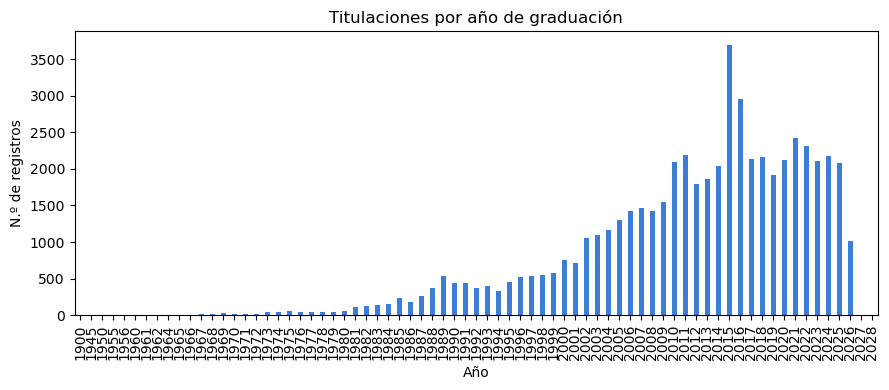

In [8]:
pc.grafico_por_anio(df['FechaGraduacion'], 'Titulaciones por año de graduación')

**Distribución por nivel de formación** (tercer nivel, cuarto nivel, etc.).

<Axes: title={'center': 'Titulaciones por nivel de formación'}, xlabel='Nivel'>

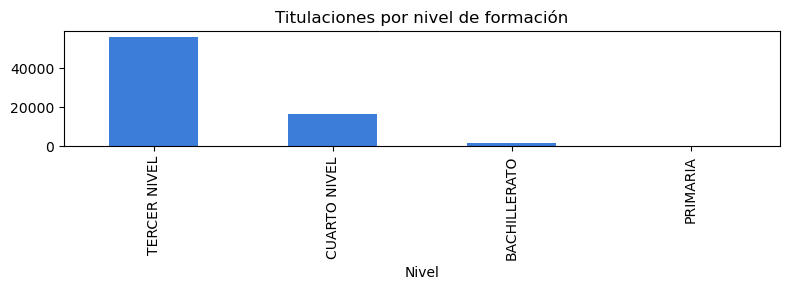

In [9]:
pc.grafico_barras(df['Nivel'], 'Titulaciones por nivel de formación', horizontal=False)

**Instituciones que más titulan al personal**.

<Axes: title={'center': 'Top 10 instituciones otorgantes'}, ylabel='Institucion'>

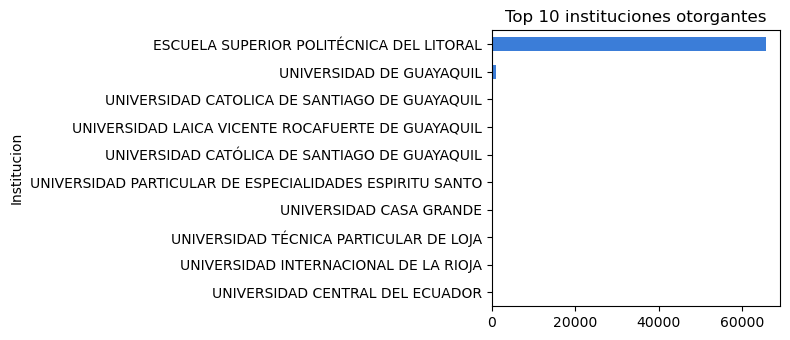

In [10]:
pc.grafico_barras(df['Institucion'], 'Top 10 instituciones otorgantes', top=10)

**Países donde se obtuvieron los títulos**.

<Axes: title={'center': 'Top 10 países de obtención del título'}, ylabel='Pais'>

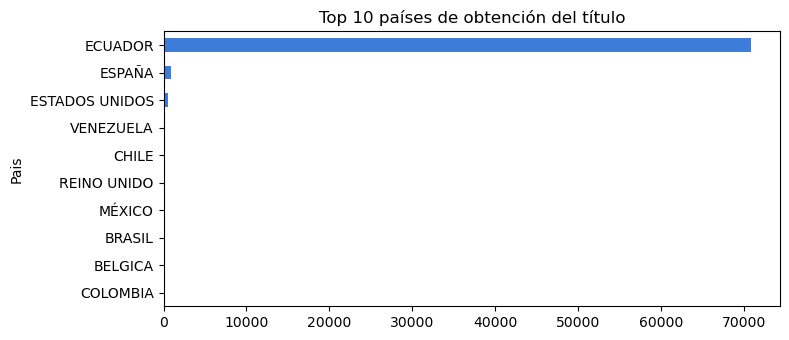

In [11]:
pc.grafico_barras(df['Pais'], 'Top 10 países de obtención del título', top=10)

## 7. Verificación final

In [12]:
pc.resumen(df, 'reporte_titulaciones_educacion (procesado)')
df.head()

--- Resumen reporte_titulaciones_educacion (procesado) ---
Dimensiones: 74553 filas x 30 columnas
Filas duplicadas: 0
Columnas con nulos (%):
FechaSubidaArchivoTitulo    98.7
SubAreaFrascati             88.1
AreaFrascati                88.1
SubAreaCine                 88.0
CampoSubCine                88.0
CampoCine                   88.0
AreaCine                    75.4
CodCarrera                  32.5
RefArchivo                  29.8
CodCarrDivEspecializ        28.8
CodEstudiante               28.8
FechaGraduacion             24.4
Pais                         0.7
Titulo                       0.5
Estado                       0.3
Institucion                  0.2
dtype: float64


,IdPersona,NumeroIdentificacion,Apellidos,Nombres,IdTitulacion,Titulo,Estado,Nivel,Institucion,Pais,CodEstudiante,CodCarrera,CodCarrDivEspecializ,AreaCine,CampoCine,SubAreaCine,CampoSubCine,AreaFrascati,SubAreaFrascati,IdNomenclaturaTit,CodAreaFrascati,CodSubAreaFrascati,FechaGraduacion,RefArchivo,FechaSubidaArchivoTitulo,ValidadoThTitulo,ValidadoThMateriasAprobadas,ValidadoThRankGraduado,ValidadoThRankIes,IdPrograma
0,27668,0000000000011,OTERO ALVARADO,CARLOS GERARDO,0,ECONOMISTA CON MENCIÓN EN GESTIÓN EMPRESARIAL ...,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199409012.0,ECO,ECECOFI,<NA>,NaN,<NA>,NaN,<NA>,<NA>,0,0,0,1999-01-14,"1,166886",NaT,1,1,1,1,10
1,25678,0000000006510,BORRERO SANABRIA,OMAR .,0,TECNÓLOGO EN PESQUERÍA,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199105685.0,PES,TEPESTP,<NA>,NaN,<NA>,NaN,<NA>,<NA>,0,0,0,1994-12-16,"1,161944",NaT,1,1,1,1,127
2,27669,0000000008715,MENJIVAR CASTANEDA,GUILLERMO SAMAEL,0,TECNÓLOGO EN AGRICULTURA,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,199409020.0,AGR,TEAGRSE,<NA>,NaN,<NA>,NaN,<NA>,<NA>,0,0,0,1997-10-21,"1,166317",NaT,1,1,1,1,113
3,15792,0000000022,GUTIERREZ SUAREZ,ISIDRO LIZARDO,0,INGENIERO EN ELECTRICIDAD ESPECIALIZACIÓN ELEC...,Graduado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,197000391.0,ELE,INELEEL,<NA>,NaN,<NA>,NaN,<NA>,<NA>,0,0,0,1986-06-27,<NA>,NaT,1,1,1,1,44
4,21955,0000000033970,POSLIGUA JULIO,MARIA LILIANA,0,Acuicultura,Egresado,TERCER NIVEL,ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,ECUADOR,198506594.0,ACU,LIACU,<NA>,NaN,<NA>,NaN,<NA>,<NA>,0,0,0,NaT,<NA>,NaT,1,1,1,1,68


## 8. Guardado en data/processed

In [13]:
pc.guardar_procesado(df, 'reporte_titulaciones_educacion.csv')

Guardado: D:\Proyecto_Tesis\data\processed\reporte_titulaciones_educacion.csv (74553 filas x 30 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/reporte_titulaciones_educacion.csv')